"""
High Energy Polarization Signatures from AGN Jets

Title:
Reproduction of Figure 3 from POLARIZATION OF PROMPT GAMMA-RAY BURST EMISSION: EVIDENCE FOR
ELECTROMAGNETICALLY DOMINATED OUTFLOW
M.Lyutikod5

Author:
Dhanad Jha

Supervisor:
Dr. Bhargav Vaidya, IIT Indore

GitHub:
https://github.com/Dhanad1905/High-Energy-Polarization-Signatures-From-AGN-Jets/tree/main

"""

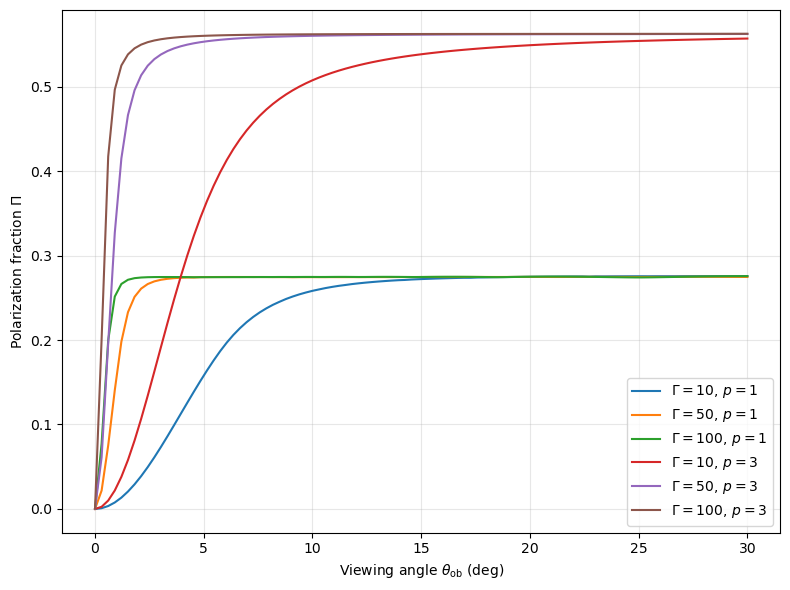

In [69]:
import numpy as np
import matplotlib.pyplot as plt
def phi_integrals(theta, theta_ob, Gamma=100, p=3, n_phi=800):
    beta = np.sqrt(1.0 - 1.0 / Gamma**2)

    phi = np.linspace(0, 2*np.pi, n_phi)

    sin_th = np.sin(theta)
    cos_th = np.cos(theta)
    sin_to = np.sin(theta_ob)
    cos_to = np.cos(theta_ob)

    sin_ph = np.sin(phi)
    cos_ph = np.cos(phi)

    mu = cos_th * cos_to + sin_th * sin_to * cos_ph

    one_minus = 1.0 - beta * mu
    one_minus = np.maximum(one_minus, 1e-14)

    D = 1.0 / (Gamma * one_minus)

    sin2_chip = 1.0 - (sin_ph**2 * sin_to**2) / (Gamma**2 * one_minus**2)
    sin2_chip = np.clip(sin2_chip, 0.0, 1.0)
    sin_chip = np.sqrt(sin2_chip)

    denom_sq = one_minus**2 - (sin_to**2 * sin_ph**2) / Gamma**2
    denom_sq = np.maximum(denom_sq, 1e-14)
    denom = np.sqrt(denom_sq)

    cos_chit = (
        one_minus * cos_ph
        - beta * sin_th * sin_to * (sin_ph**2)
    ) / denom

    sin_chit = (
        sin_ph * (beta * cos_th - cos_to)
    ) / denom

    cos2_chit = cos_chit**2 - sin_chit**2

    weight = (
        D**(2 + (p - 1) / 2)
        * sin_chip**((p + 1) / 2)
        * sin_th
    )

    numerator_phi = np.trapz(weight * cos2_chit, phi)
    denominator_phi = np.trapz(weight, phi)

    return numerator_phi, denominator_phi

def polarization_fraction_adaptive(theta_ob, Gamma=100, p=3,
                                   theta_window_factor=8.0,
                                   n_phi=800,
                                   tol=1e-4,
                                   max_iter=12):

    prefac = (p + 1) / (p + 7/3)

    delta = theta_window_factor / Gamma
    theta_min = max(0.0, theta_ob - delta)
    theta_max = min(np.pi, theta_ob + delta)

    if theta_ob < delta:
        theta_min = 0.0

    theta_grid = np.linspace(theta_min, theta_max, 25)

    for _ in range(max_iter):
        num_vals = []
        den_vals = []

        for th in theta_grid:
            num_phi, den_phi = phi_integrals(th, theta_ob, Gamma, p, n_phi=n_phi)
            num_vals.append(num_phi)
            den_vals.append(den_phi)

        num_vals = np.array(num_vals)
        den_vals = np.array(den_vals)

        numerator_old = np.trapz(num_vals, theta_grid)
        denominator_old = np.trapz(den_vals, theta_grid)
        Pi_old = prefac * numerator_old / denominator_old

        theta_mid = 0.5 * (theta_grid[:-1] + theta_grid[1:])
        theta_refined = np.sort(np.concatenate([theta_grid, theta_mid]))

        num_vals_ref = []
        den_vals_ref = []

        for th in theta_refined:
            num_phi, den_phi = phi_integrals(th, theta_ob, Gamma, p, n_phi=n_phi)
            num_vals_ref.append(num_phi)
            den_vals_ref.append(den_phi)

        num_vals_ref = np.array(num_vals_ref)
        den_vals_ref = np.array(den_vals_ref)

        numerator_new = np.trapz(num_vals_ref, theta_refined)
        denominator_new = np.trapz(den_vals_ref, theta_refined)
        Pi_new = prefac * numerator_new / denominator_new

        if abs(Pi_new - Pi_old) < tol:
            return Pi_new

        theta_grid = theta_refined

    return Pi_new
Gammas = [10, 50, 100]
p_values = [1, 3]

theta_deg = np.linspace(0.01, 30, 100)
theta_rad = np.deg2rad(theta_deg)

plt.figure(figsize=(8, 6))

for p in p_values:
    for G in Gammas:
        Pi_vals = np.array([
            polarization_fraction_adaptive(
                th,
                Gamma=G,
                p=p,
                theta_window_factor=8.0,
                n_phi=800,
                tol=1e-4,
                max_iter=10
            )
            for th in theta_rad
        ])

        label = rf"$\Gamma={G},\,p={p}$"
        plt.plot(theta_deg, Pi_vals, label=label)

plt.xlabel(r"Viewing angle $\theta_{\rm ob}$ (deg)")
plt.ylabel(r"Polarization fraction $\Pi$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()